In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [2]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [3]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
PG = {'sigma_log':[0.10,0.15,0.20,0.25,0.30], 'GGE':[0.20,0.25,0.31,0.37,0.43], 'w_sink':[5.0,10.0],
      'k_remin':[0.04], 'mP':[0.0015], 'm_Z':[0.10], 'KsZ':[0.23]}        # k_remin 0.04 (lit); 5×5×2 = 50/era
ssh.describe_run('maranon_ward', FORC['pre+recovery'], fish_rate=0.5, routed=True, n_harmonics=3, mP=0.0015, m_Z=0.10,
                 iv_overrides={'GrazingRouter':{'gge':0.31},'Grazing':{'KsZ':0.23,'sigma_log':0.20},
                               'DetritusRemin':{'k_remin':0.04},'DetritusSink':{'w_sink':5.0}})
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=[0.5],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_sigGGE_pre_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.5
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     zoo linear : N 0.00 / D 1.00 / export 0.00
     zoo quad   : N 0.67 / D 0.00 / export 0.33
     fish       : N 0.50 / D 0.00 / export 0.50
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
[seasonal scan] 50 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.5] x params['sigma_log', 'GGE', 'w_sink', 'k_remin', 'mP', 'm_Z', 'KsZ'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_s

In [4]:
ssh.describe_run('maranon_ward', FORC['post'], fish_rate=0.1, routed=True, n_harmonics=3, mP=0.0015, m_Z=0.10,
                 iv_overrides={'GrazingRouter':{'gge':0.31},'Grazing':{'KsZ':0.23,'sigma_log':0.20},
                               'DetritusRemin':{'k_remin':0.04},'DetritusSink':{'w_sink':5.0}})
res_post = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=[0.1],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_sigGGE_post_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print('post done:', len(res_post.records))

  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     zoo linear : N 0.00 / D 1.00 / export 0.00
     zoo quad   : N 0.67 / D 0.00 / export 0.33
     fish       : N 0.50 / D 0.00 / export 0.50
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[0.75-4.80]  d_e[34-56]  T[22.9-27.2]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
[seasonal scan] 50 runs: ['maranon_ward'] x ['post'] x fish=[0.1] x params['sigma_log', 'GGE', 'w_sink', 'k_remin', 'mP', 'm_Z', 'KsZ'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.

In [5]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_sigGGE_pre_2026-06-28.pkl'); RQ=ssh.load_results('seasonal_sigGGE_post_2026-06-28.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; TGT=['mcs','pico','nano','micro','sumP']; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']
def fitrec(r,g):
    def rms(suf,ov):
        t=[((r.get(k+suf,np.nan)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(r.get(k+suf,np.nan))]
        return np.sqrt(np.mean(t)) if t else np.nan
    return float(np.nanmax([rms('',OBS[g]['mean']),rms('_med',OBS[g]['med'])]))
key=lambda r:(round(r['sigma_log'],4),round(r['GGE'],4),round(r['w_sink'],4))
P={key(r):r for r in RP.records}; Q={key(r):r for r in RQ.records}; rows=[]
for k,p in P.items():
    q=Q[k]; sg,gg,ws=k; cz=np.asarray(q.get('clim_sumP',[np.nan]*12),float); fp,fq=fitrec(p,'pre+recovery'),fitrec(q,'post')
    rows.append(dict(sigma=sg,GGE=gg,w_sink=ws,joint=max(fp,fq),fit_pre=fp,fit_post=fq,
        Zmed_inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan),post_maxP=float(np.nanmax(cz)),
        post_bl=MO[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '·',pre_cv=p.get('cv_sumP',np.nan),pze=q.get('pze',np.nan)))
D=pd.DataFrame(rows)
print(f"σ×GGE×w_sink re-fit (routed, k_remin 0.04) | obs med Z inv {od:+.4f} | Mouw pze ~0.50")
ok=D[D.Zmed_inv>0].sort_values('joint')
print(f"\ncascade-positive, best joint fit first ({len(ok)}/{len(D)}):")
print(ok.head(15).round({'sigma':2,'GGE':2,'w_sink':1,'joint':3,'fit_pre':3,'fit_post':3,'Zmed_inv':4,'post_maxP':3,'pre_cv':2,'pze':2}).to_string(index=False))

σ×GGE×w_sink re-fit (routed, k_remin 0.04) | obs med Z inv +0.0035 | Mouw pze ~0.50

cascade-positive, best joint fit first (32/50):
 sigma  GGE  w_sink  joint  fit_pre  fit_post  Zmed_inv  post_maxP post_bl  pre_cv  pze
  0.20 0.31     5.0  0.243    0.198     0.243    0.0015      0.674       M    1.06 0.56
  0.30 0.25     5.0  0.275    0.221     0.275    0.0032      0.647       M    1.34 0.56
  0.25 0.25    10.0  0.320    0.221     0.320    0.0093      0.906       A    1.33 0.65
  0.15 0.37     5.0  0.326    0.249     0.326    0.0006      0.754       M    0.80 0.56
  0.30 0.31    10.0  0.340    0.340     0.322    0.0011      0.575       A    1.23 0.64
  0.30 0.25    10.0  0.396    0.305     0.396    0.0041      0.612       M    1.45 0.65
  0.20 0.43     5.0  0.415    0.415     0.354    0.0030      0.512       M    0.85 0.56
  0.20 0.43    10.0  0.422    0.422     0.332    0.0070      0.511       M    0.85 0.64
  0.15 0.37    10.0  0.444    0.256     0.444    0.0045      0.681       M 

In [3]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)         # committed all-cruise DOY
PG = {'k_remin':[0.02,0.04,0.06,0.08,0.10], 'w_sink':[2.5,5.0,7.5,10.0],
      'GGE':[0.31],'KsZ':[0.23],'sigma_log':[0.20],'mP':[0.0015],'m_Z':[0.10]}   # construct D held; 5×4=20 combos
ssh.describe_run('maranon_ward', FORC['pre+recovery'], fish_rate=0.5, routed=True, mP=0.0015, m_Z=0.10,
                 iv_overrides={'GrazingRouter':{'gge':0.31},'Grazing':{'KsZ':0.23,'sigma_log':0.20},
                               'DetritusRemin':{'k_remin':0.04},'DetritusSink':{'w_sink':10.0}})   # confirm before launch
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=[0.5],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_detritus2D_pre_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.5
  detritus: k_remin 0.04  w_sink 10.0  ->  L = 250 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     zoo linear : N 0.00 / D 1.00 / export 0.00
     zoo quad   : N 0.67 / D 0.00 / export 0.33
     fish       : N 0.50 / D 0.00 / export 0.50
  forcing : n_harmonics 2  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
[seasonal scan] 20 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.5] x params['k_remin', 'w_sink', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_

In [4]:
ssh.describe_run('maranon_ward', FORC['post'], fish_rate=0.1, routed=True, mP=0.0015, m_Z=0.10,
                 iv_overrides={'GrazingRouter':{'gge':0.31},'Grazing':{'KsZ':0.23,'sigma_log':0.20},
                               'DetritusRemin':{'k_remin':0.04},'DetritusSink':{'w_sink':10.0}})
res_post = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=[0.1],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_detritus2D_post_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print('post done:', len(res_post.records))

  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 10.0  ->  L = 250 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     zoo linear : N 0.00 / D 1.00 / export 0.00
     zoo quad   : N 0.67 / D 0.00 / export 0.33
     fish       : N 0.50 / D 0.00 / export 0.50
  forcing : n_harmonics 2  fit @ cruise DOY  | F_N[0.75-4.80]  d_e[34-56]  T[22.9-27.2]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
[seasonal scan] 20 runs: ['maranon_ward'] x ['post'] x fish=[0.1] x params['k_remin', 'w_sink', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1

In [7]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_detritus2D_pre_2026-06-28.pkl'); RQ=ssh.load_results('seasonal_detritus2D_post_2026-06-28.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}      # each pickle's obs holds only its era
TGT=['mcs','pico','nano','micro','sumP']; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']; de_e=np.nanmean(RQ.forcings['post']['de'])
def fitrec(r,g):
    def rms(suf,ov):
        t=[((r.get(k+suf,np.nan)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(r.get(k+suf,np.nan))]
        return np.sqrt(np.mean(t)) if t else np.nan
    return float(np.nanmax([rms('',OBS[g]['mean']),rms('_med',OBS[g]['med'])]))
P={(round(r['k_remin'],4),round(r['w_sink'],4)):r for r in RP.records}; Q={(round(r['k_remin'],4),round(r['w_sink'],4)):r for r in RQ.records}
rows=[]
for (kr,ws),p in sorted(P.items()):
    q=Q[(kr,ws)]; cz=np.asarray(q.get('clim_sumP',[np.nan]*12),float)
    rows.append(dict(k_rem=kr,w_sink=ws,L=ws/kr,retn=kr/(kr+ws/de_e),fit_pre=fitrec(p,'pre+recovery'),fit_post=fitrec(q,'post'),
        Zmed_inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan),post_maxP=float(np.nanmax(cz)),
        post_bl=MO[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '·',pre_cv=p.get('cv_sumP',np.nan),
        pze_post=q.get('pze',np.nan)))
D=pd.DataFrame(rows)
print(f"detritus 2D (routed) | obs med Z inv {od:+.4f} | Mouw pze ~0.50 | retention @ d_e≈{de_e:.0f} m")
print(D.round({'L':0,'retn':2,'fit_pre':3,'fit_post':3,'Zmed_inv':4,'post_maxP':3,'pre_cv':2,'pze_post':2}).to_string(index=False))

detritus 2D (routed) | obs med Z inv +0.0035 | Mouw pze ~0.50 | retention @ d_e≈48 m
 k_rem  w_sink     L  retn  fit_pre  fit_post  Zmed_inv  post_maxP post_bl  pre_cv  pze_post
  0.02     2.5 125.0  0.28    0.188     0.236    0.0016      0.698       M    0.99      0.57
  0.02     5.0 250.0  0.16    0.299     0.312   -0.0007      0.693       M    1.23      0.65
  0.02     7.5 375.0  0.11    0.273     0.349    0.0002      0.668       M    1.19      0.68
  0.02    10.0 500.0  0.09    0.266     0.382   -0.0008      0.656       M    1.21      0.70
  0.04     2.5  62.0  0.43    0.240     0.173   -0.0022      0.922       A    1.06      0.45
  0.04     5.0 125.0  0.28    0.206     0.243    0.0012      0.674       M    1.07      0.56
  0.04     7.5 188.0  0.20    0.300     0.256    0.0001      0.680       M    1.29      0.62
  0.04    10.0 250.0  0.16    0.274     0.338   -0.0020      0.674       M    1.27      0.65
  0.06     2.5  42.0  0.53    0.217     0.156    0.0074      1.008       A    

In [8]:
import numpy as np, seasonal_scan_harness as ssh
FISH={'pre+recovery':0.5,'post':0.1}; ERAS=['pre+recovery','post']
spec=ssh.allometry('maranon_ward'); FORC=ssh.build_forcings(ERAS,hplc_coincident=False)
CANDS={'lit 0.04/5':(0.04,5.0),'perf 0.06/2.5':(0.06,2.5),'asbuilt 0.10/5':(0.10,5.0),'fulllit 0.04/10':(0.04,10.0)}
SEL='lit 0.04/5'        # ← which combo to load into the overview
def run(g,kr,ws):
    return ssh.run_one(spec,FORC[g],fish_rate=FISH[g],years=60,spinup=15,routed=True,n_harmonics=3,
        mP=0.0015,m_Z=0.10,grazing={'KsZ':0.23,'sigma_log':0.20},
        iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusRemin':{'k_remin':kr},'DetritusSink':{'w_sink':ws}},
        return_traj=True)
RUNS={}
for lab,(kr,ws) in CANDS.items():
    cp,rp=run('pre+recovery',kr,ws); cq,rq=run('post',kr,ws); RUNS[lab]={'pre+recovery':rp,'post':rq}
    kp,kq=rp['t']>=15*365, rq['t']>=15*365
    print(f"{lab:<16} pze_post={cq['pze']:.2f}  Zmed_inv={np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):+.4f}")
runs=RUNS[SEL]; PICKLES=[f"routed {SEL}"]; PICKLE_IDX=0
print(f"\nloaded '{SEL}' into `runs` for the overview (flip SEL, or runs=RUNS['perf 0.06/2.5'])")

lit 0.04/5       pze_post=0.56  Zmed_inv=+0.0015
perf 0.06/2.5    pze_post=0.37  Zmed_inv=+0.0075
asbuilt 0.10/5   pze_post=0.40  Zmed_inv=+0.0073
fulllit 0.04/10  pze_post=0.65  Zmed_inv=-0.0020

loaded 'lit 0.04/5' into `runs` for the overview (flip SEL, or runs=RUNS['perf 0.06/2.5'])


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_38750/2811945049.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


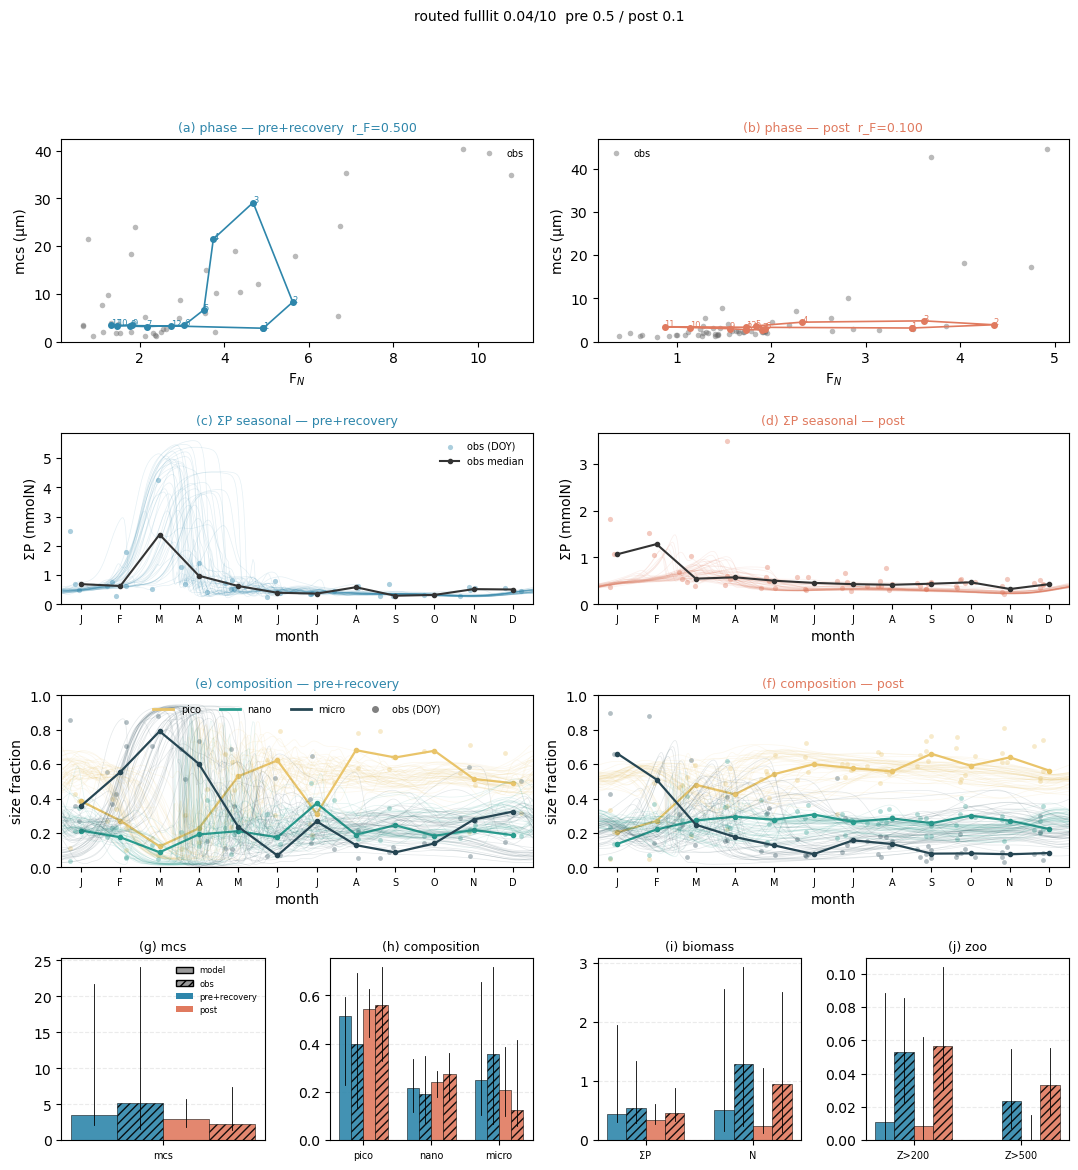

In [11]:
SEL = 'fulllit 0.04/10'   # ← cycle: 'lit 0.04/5' | 'perf 0.06/2.5' | 'asbuilt 0.10/5' | 'fulllit 0.04/10'
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"routed {SEL}  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.show()

In [11]:
import numpy as np, seasonal_scan_harness as ssh
import baseline_r0_seasonal_setups as brss          # restart kernel first (new files copied in)

# routed run = ssh.run_one with model+builder swapped (reuses run_one's DOY/_reduce/_clim logic)
def run_routed(*a, **kw):
    _m, _b = ssh.model_baseline_seasonal, ssh.make_seasonal_input_vars
    ssh.model_baseline_seasonal   = brss.model_baseline_seasonal_routed
    ssh.make_seasonal_input_vars  = brss.make_seasonal_input_vars_routed
    try:    return ssh.run_one(*a, **kw)
    finally: ssh.model_baseline_seasonal, ssh.make_seasonal_input_vars = _m, _b

FISH={'pre+recovery':0.4,'post':0.2}; ERAS=['pre+recovery','post']
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
spec=ssh.allometry('maranon_ward'); OBS=ssh.build_obs_targets(ERAS)
FORC=ssh.build_forcings(ERAS, hplc_coincident=False)                     # committed baseline forcing
CD=dict(mP=0.0015, m_Z=0.10, grazing={'KsZ':0.23,'sigma_log':0.20},
        iv_overrides={'GrazingRouter':{'gge':0.31}}, n_harmonics=3)       # construct D scalars
def clim(r,k):
    keep=r['t']>=15*365; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365),'right')+1,1,12); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in range(1,13)])
def fit(r,g):
    k=r['t']>=15*365; mv={m:np.nanmean(r[m][k]) for m in TGT}; md={m:np.nanmedian(r[m][k]) for m in TGT}
    def rms(x,ov):
        t=[((x[m]-ov[m])/ov[m])**2 for m in TGT if ov.get(m) and abs(ov[m])>1e-9 and np.isfinite(x[m])]
        return np.sqrt(np.mean(t)) if t else np.nan
    return max(rms(mv,OBS[g]['mean']),rms(md,OBS[g]['med']))
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']; RUNS={}
print(f"current vs routed @ baseline (all-cruise 3h DOY, construct D, 0.5/0.1) | obs med Z inv {od:+.4f}, obs post N {OBS['post']['med']['N']:.2f}")
print(f"{'config':>8}{'fit_pre':>8}{'fit_post':>9}{'pre_mcs':>8}{'post_mcs':>9}{'post_ΣPmed':>11}{'post_maxP':>10}{'post_bl':>8}{'pre_Nmed':>9}{'post_Nmed':>10}{'Zmed_inv':>10}")
for tag,runner in [('current',ssh.run_one),('routed',run_routed)]:
    rp=runner(spec,FORC['pre+recovery'],fish_rate=0.5,years=60,spinup=15,return_traj=True,**CD)[1]
    rq=runner(spec,FORC['post'],fish_rate=0.1,years=60,spinup=15,return_traj=True,**CD)[1]
    RUNS[tag]={'pre+recovery':rp,'post':rq}
    kp,kq=rp['t']>=15*365, rq['t']>=15*365; cz=clim(rq,'sumP')
    print(f"{tag:>8}{fit(rp,'pre+recovery'):>8.3f}{fit(rq,'post'):>9.3f}{np.nanmedian(rp['mcs'][kp]):>8.2f}{np.nanmedian(rq['mcs'][kq]):>9.2f}"
          f"{np.nanmedian(rq['sumP'][kq]):>11.3f}{np.nanmax(cz):>10.3f}{MO[int(np.nanargmax(cz))]:>8}"
          f"{np.nanmedian(rp['N'][kp]):>9.3f}{np.nanmedian(rq['N'][kq]):>10.3f}"
          f"{np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):>+10.4f}")
runs=RUNS['routed']; PICKLES=['routed baseline 0.5/0.1']; PICKLE_IDX=0
print("\nloaded 'routed' into `runs` for the overview (set runs=RUNS['current'] to A/B in the overview)")

current vs routed @ baseline (all-cruise 3h DOY, construct D, 0.5/0.1) | obs med Z inv +0.0035, obs post N 0.96
  config fit_pre fit_post pre_mcs post_mcs post_ΣPmed post_maxP post_bl pre_Nmed post_Nmed  Zmed_inv
 current   0.228    0.167    3.65     2.22      0.388     0.956       A    0.829     0.508   +0.0026
  routed   0.210    0.161    3.73     2.23      0.412     0.901       A    1.177     0.597   +0.0071

loaded 'routed' into `runs` for the overview (set runs=RUNS['current'] to A/B in the overview)


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_35759/3949677552.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


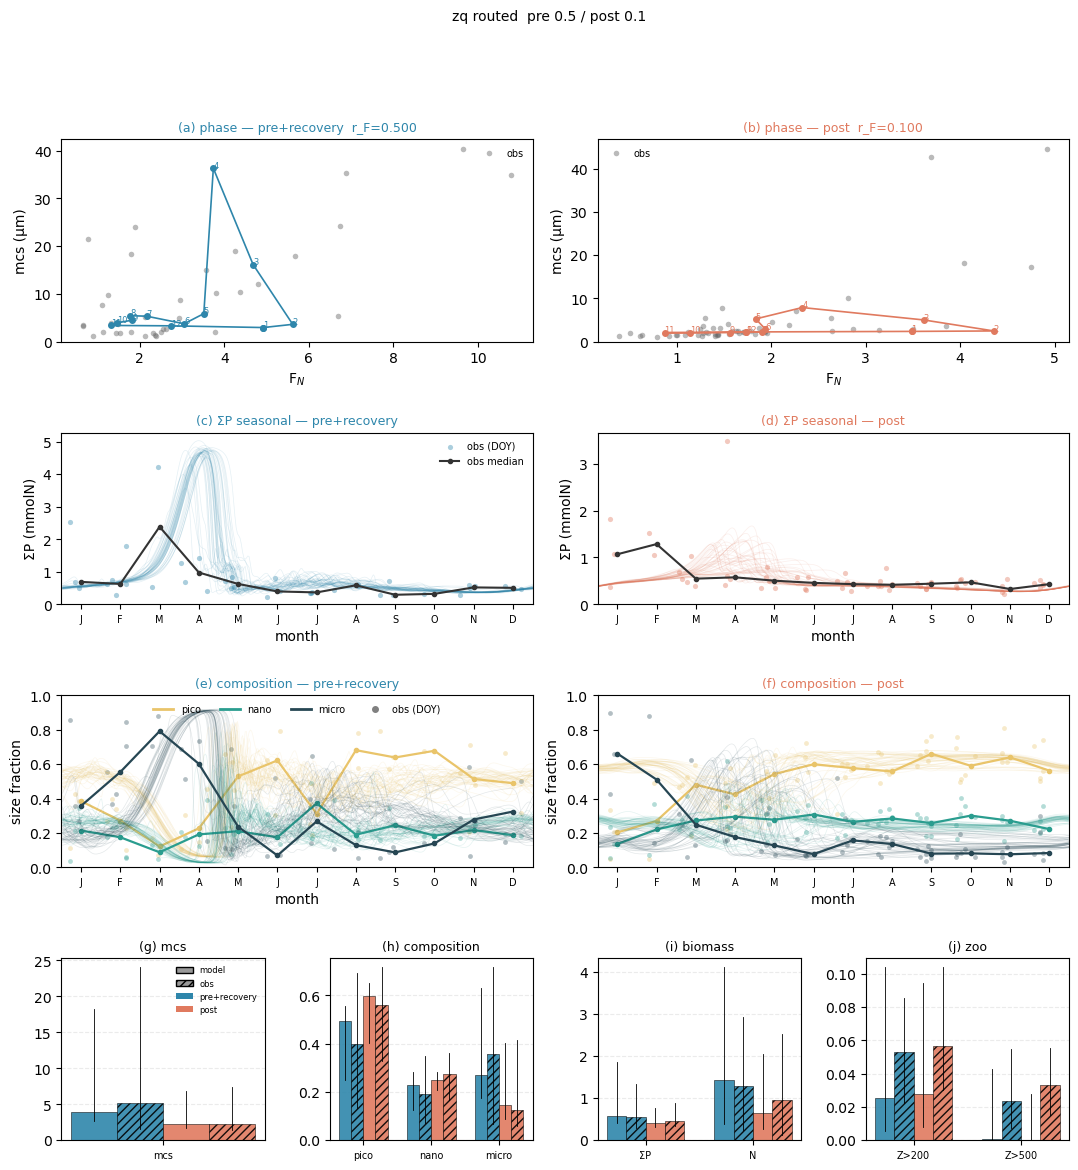

In [12]:
SEL = 'routed'   # ← cycle: 'current' | 'routed' 
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"zq {SEL}  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()

In [6]:
import numpy as np
def stab(r):
    k=r['t']>=15*365; t=r['t'][k]; sp=r['sumP'][k]; yr=(t/365).astype(int)
    cv=np.nanstd(sp)/max(np.nanmean(sp),1e-9)
    ann=np.array([np.nanmean(sp[yr==y]) for y in np.unique(yr)]); iav=np.nanstd(ann)/max(np.nanmean(ann),1e-9)
    mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365),'right')+1,1,12); bms=[]
    for y in np.unique(yr):
        m=yr==y; mm=np.array([np.nanmean(sp[m][mo[m]==i]) if np.any(mo[m]==i) else np.nan for i in range(1,13)])
        if np.isfinite(mm).any(): bms.append(int(np.nanargmax(mm))+1)
    bms=np.array(bms); return cv,iav,(np.nanmin(r['minP'][k]) if 'minP' in r else np.nan),bms.min(),bms.max(),bool(np.isnan(sp).any())
print(f"{'config':>8}{'era':>14}{'cv_ΣP':>7}{'IAV_ΣP':>8}{'minP':>9}{'bloom_rng':>11}{'NaN':>5}")
for tag in ('current','routed'):
    for g in ['pre+recovery','post']:
        cv,iav,mp,b0,b1,nan=stab(RUNS[tag][g])
        print(f"{tag:>8}{g:>14}{cv:>7.2f}{iav:>8.3f}{mp:>9.4f}{MO[b0-1]+'–'+MO[b1-1]:>11}{str(nan):>5}")

  config           era  cv_ΣP  IAV_ΣP     minP  bloom_rng  NaN
 current  pre+recovery   0.99   0.080   0.0000        M–AFalse
 current          post   0.45   0.008   0.0000        A–AFalse
  routed  pre+recovery   1.09   0.064   0.0000        M–AFalse
  routed          post   0.44   0.023   0.0000        M–JFalse


In [8]:
import numpy as np, seasonal_scan_harness as ssh, baseline_r0_seasonal_setups as brss
def run_routed(*a,**kw):
    _m,_b=ssh.model_baseline_seasonal,ssh.make_seasonal_input_vars
    ssh.model_baseline_seasonal,ssh.make_seasonal_input_vars=brss.model_baseline_seasonal_routed,brss.make_seasonal_input_vars_routed
    try: return ssh.run_one(*a,**kw)
    finally: ssh.model_baseline_seasonal,ssh.make_seasonal_input_vars=_m,_b
FISH={'pre+recovery':0.5,'post':0.1}; ERAS=['pre+recovery','post']
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
spec=ssh.allometry('maranon_ward'); OBS=ssh.build_obs_targets(ERAS); FORC=ssh.build_forcings(ERAS,hplc_coincident=False)
def CD(ws,kr):
    return dict(mP=0.0015,m_Z=0.10,grazing={'KsZ':0.23,'sigma_log':0.20},
                iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusSink':{'w_sink':ws},'DetritusRemin':{'k_remin':kr}},
                n_harmonics=3)
CFG={'as-built 5/0.10':(5.0,0.10),'lit 10/0.04':(10.0,0.04)}
def clim(r,k):
    keep=r['t']>=15*365; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365),'right')+1,1,12); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in range(1,13)])
def fit(r,g):
    k=r['t']>=15*365; mv={m:np.nanmean(r[m][k]) for m in TGT}; md={m:np.nanmedian(r[m][k]) for m in TGT}
    def rms(x,ov):
        t=[((x[m]-ov[m])/ov[m])**2 for m in TGT if ov.get(m) and abs(ov[m])>1e-9 and np.isfinite(x[m])]
        return np.sqrt(np.mean(t)) if t else np.nan
    return max(rms(mv,OBS[g]['mean']),rms(md,OBS[g]['med']))
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']; RUNS={}
print(f"routed detritus check @ baseline (all-cruise 3h DOY, construct D, 0.5/0.1) | obs med Z inv {od:+.4f}, obs post N {OBS['post']['med']['N']:.2f}")
print(f"{'config':>16}{'L':>5}{'fit_pre':>8}{'fit_post':>9}{'pre_mcs':>8}{'post_mcs':>9}{'post_ΣP':>8}{'post_maxP':>10}{'post_bl':>8}{'pre_cv':>7}{'pre_N':>7}{'post_N':>7}{'Zmed_inv':>10}")
for lab,(ws,kr) in CFG.items():
    rp=run_routed(spec,FORC['pre+recovery'],fish_rate=0.5,years=60,spinup=15,return_traj=True,**CD(ws,kr))[1]
    rq=run_routed(spec,FORC['post'],fish_rate=0.1,years=60,spinup=15,return_traj=True,**CD(ws,kr))[1]
    RUNS[lab]={'pre+recovery':rp,'post':rq}
    kp,kq=rp['t']>=15*365, rq['t']>=15*365; cz=clim(rq,'sumP')
    pcv=np.nanstd(rp['sumP'][kp])/max(np.nanmean(rp['sumP'][kp]),1e-9)
    print(f"{lab:>16}{ws/kr:>5.0f}{fit(rp,'pre+recovery'):>8.3f}{fit(rq,'post'):>9.3f}{np.nanmedian(rp['mcs'][kp]):>8.2f}{np.nanmedian(rq['mcs'][kq]):>9.2f}"
          f"{np.nanmedian(rq['sumP'][kq]):>8.3f}{np.nanmax(cz):>10.3f}{MO[int(np.nanargmax(cz))]:>8}{pcv:>7.2f}"
          f"{np.nanmedian(rp['N'][kp]):>7.2f}{np.nanmedian(rq['N'][kq]):>7.2f}"
          f"{np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):>+10.4f}")
runs=RUNS['lit 10/0.04']; PICKLES=['routed lit-detritus 10/0.04']; PICKLE_IDX=0
print("\nloaded 'lit 10/0.04' into `runs` for the overview (set runs=RUNS['as-built 5/0.10'] to A/B)")

routed detritus check @ baseline (all-cruise 3h DOY, construct D, 0.5/0.1) | obs med Z inv +0.0035, obs post N 0.96
          config    L fit_pre fit_post pre_mcs post_mcs post_ΣP post_maxP post_bl pre_cv  pre_N post_N  Zmed_inv
 as-built 5/0.10   50   0.210    0.161    3.73     2.23   0.412     0.901       A   1.09   1.18   0.60   +0.0071
     lit 10/0.04  250   0.274    0.338    3.31     2.89   0.343     0.674       M   1.27   0.50   0.23   -0.0021

loaded 'lit 10/0.04' into `runs` for the overview (set runs=RUNS['as-built 5/0.10'] to A/B)


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_35759/4271659642.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


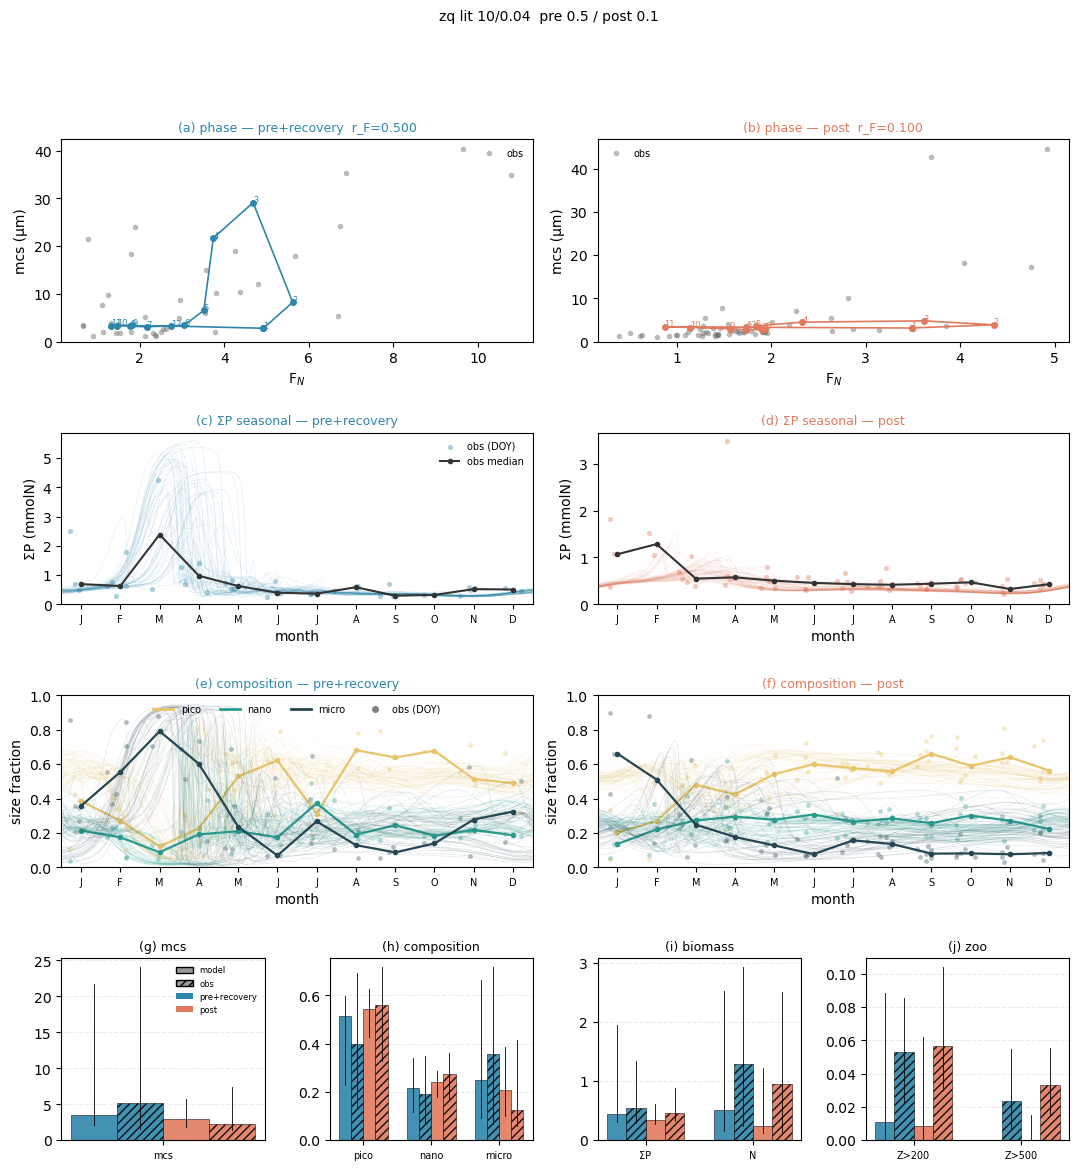

In [9]:
SEL = 'lit 10/0.04'   # ← cycle: 'as-built 5/0.10' | 'lit 10/0.04' 
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"zq {SEL}  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()